In [1]:
#Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [2]:
#Loading the dataset
tips = sns.load_dataset('tips')
#viewing the first 4 rows of the dataset
tips.head(4)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2


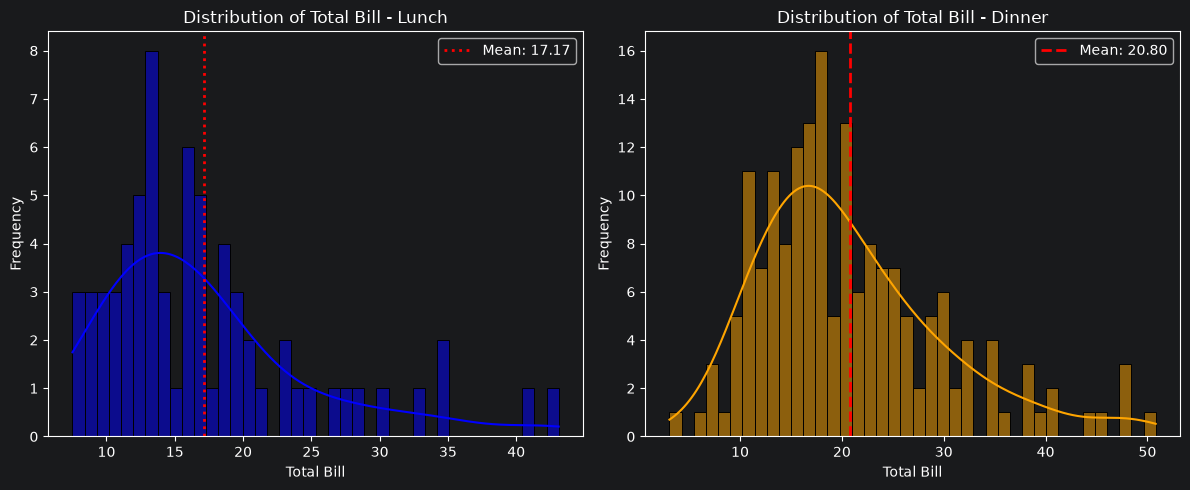

In [3]:
# Create separate dataframes for lunch and dinner
lunch_data = tips[tips["time"] == "Lunch"]
dinner_data = tips[tips["time"] == "Dinner"]

# Set up the figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram for lunch data
sns.histplot(lunch_data["total_bill"], kde=True, color='blue', bins=40, ax=axes[0])
mean_lunch = lunch_data["total_bill"].mean()
axes[0].axvline(mean_lunch, color='red', linestyle='dotted', linewidth=2, label=f"Mean: {mean_lunch:.2f}")
axes[0].set_xlabel("Total Bill")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Total Bill - Lunch")
axes[0].legend()

# Plot histogram for dinner data
sns.histplot(dinner_data["total_bill"], kde=True, color='orange', bins=40, ax=axes[1])
mean_dinner = dinner_data["total_bill"].mean()
axes[1].axvline(mean_dinner, color='red', linestyle='dashed', linewidth=2, label=f"Mean: {mean_dinner:.2f}")
axes[1].set_xlabel("Total Bill")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Total Bill - Dinner")
axes[1].legend()

#Show the plot
plt.tight_layout()
plt.show()


In [4]:
# Apply the default theme
sns.set_theme()

#loading the penguins dataset
penguins = sns.load_dataset("penguins")

#viewing the first 4 rows of the dataset
penguins.head(4)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN


In [5]:
# Get the feature names (column names) from the DataFrame
feature_names = penguins.columns

# Get the unique class names (species)
class_names = penguins["species"].unique()

# Print the feature names and class names
print("Feature Names:", feature_names)
print("Class Names:", class_names)

Feature Names: Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')
Class Names: <StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str


In [6]:
# Check for missing values in the DataFrame
#isnull() method returns a DataFrame of the same shape as penguins, where each entry is True if the corresponding value is NaN (missing) and False otherwise.
#sum() method is then applied to count the number of True values (missing values) in each column.
#can use second method directly to get the count of missing values in each column using isnull().sum().
missing_values = penguins.isnull()

# Count missing values in each column
missing_counts = penguins.isnull().sum()


# Display the counts of missing values in each column
print("\nCounts of missing values in each column:")
print(missing_counts)


Counts of missing values in each column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [7]:
# Remove rows with any missing values (NaN)
penguins = penguins.dropna()

# Count the number of missing values after removing
print("\nNumber of missing values after removing:")
print(penguins.isnull().sum())


Number of missing values after removing:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


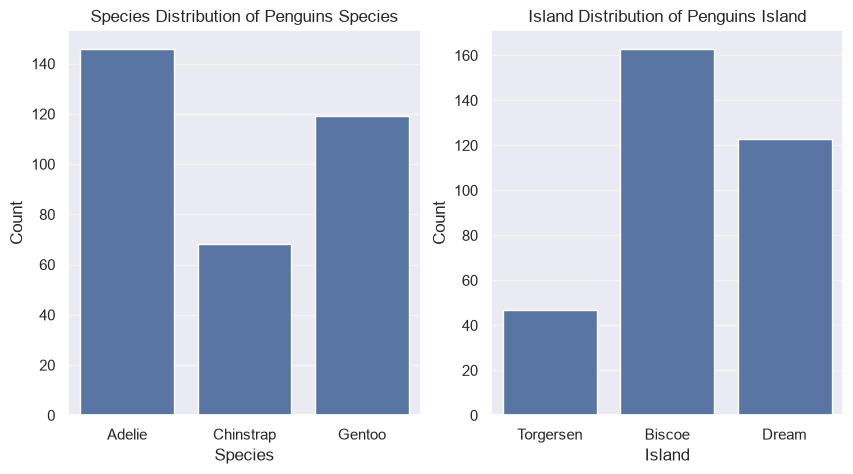

In [8]:
# Plot the class distribution
fig, ax = plt.subplots(1,2,figsize=(10, 5))
sns.countplot(data=penguins, x="species", ax=ax[0])
ax[0].set_xlabel('Species')
ax[0].set_ylabel('Count')
ax[0].set_title('Species Distribution of Penguins Species')

sns.countplot(data=penguins, x="island", ax=ax[1])
ax[1].set_xlabel('Island')
ax[1].set_ylabel('Count')
ax[1].set_title('Island Distribution of Penguins Island')

plt.show()

In [9]:
# Display information about the dataset
print(penguins.info())

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB
None


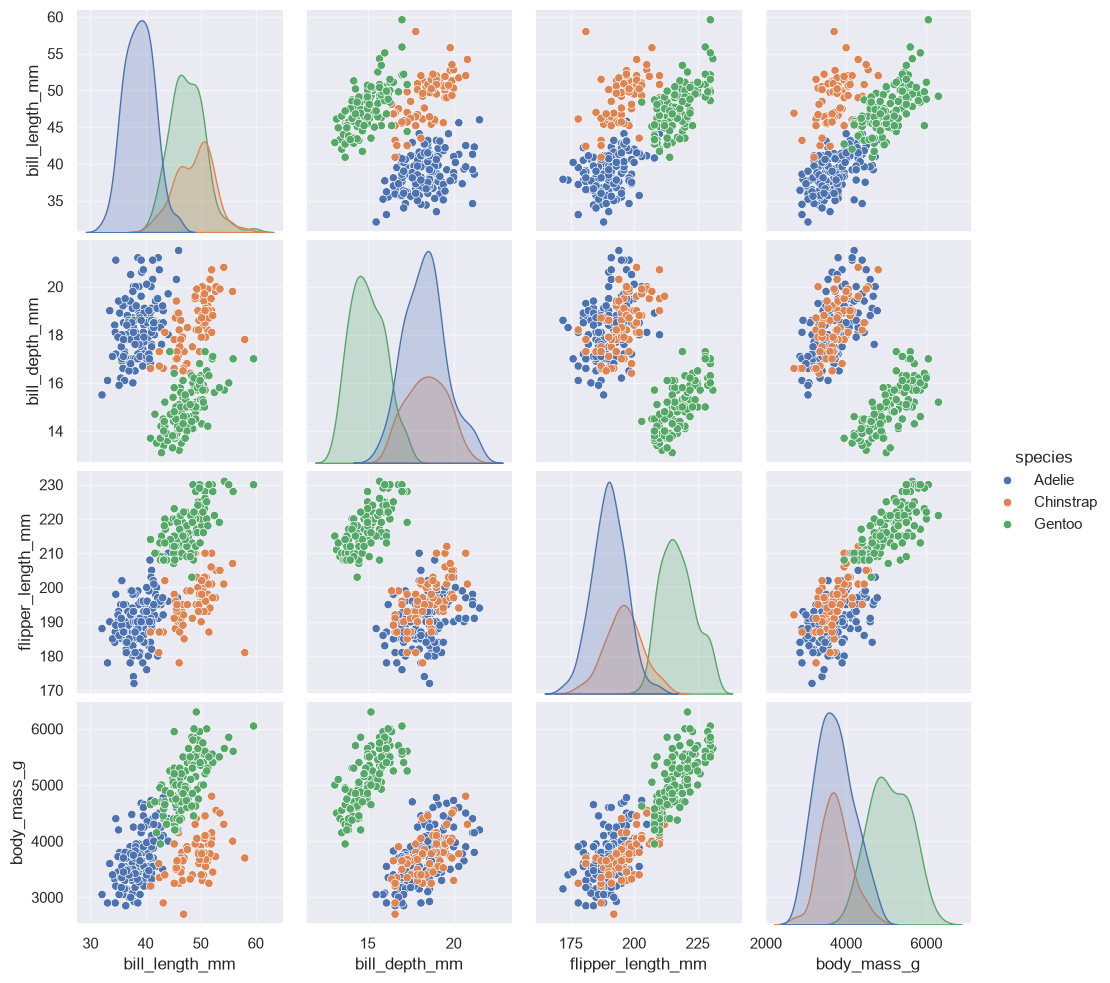

In [10]:
# Calculate covariance matrix and variance for each variable
numeric_columns = penguins.select_dtypes(include=[np.number])
cov_matrix = numeric_columns.cov()
variance_values = numeric_columns.var()

# Create the pairplot with covariance plots
g = sns.pairplot(data=penguins, hue="species", diag_kind="kde")
plt.show()

In [11]:
# Summary statistics for the penguins DataFrame
summary_stats = penguins.describe()

# Print the summary statistics
print(summary_stats)

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


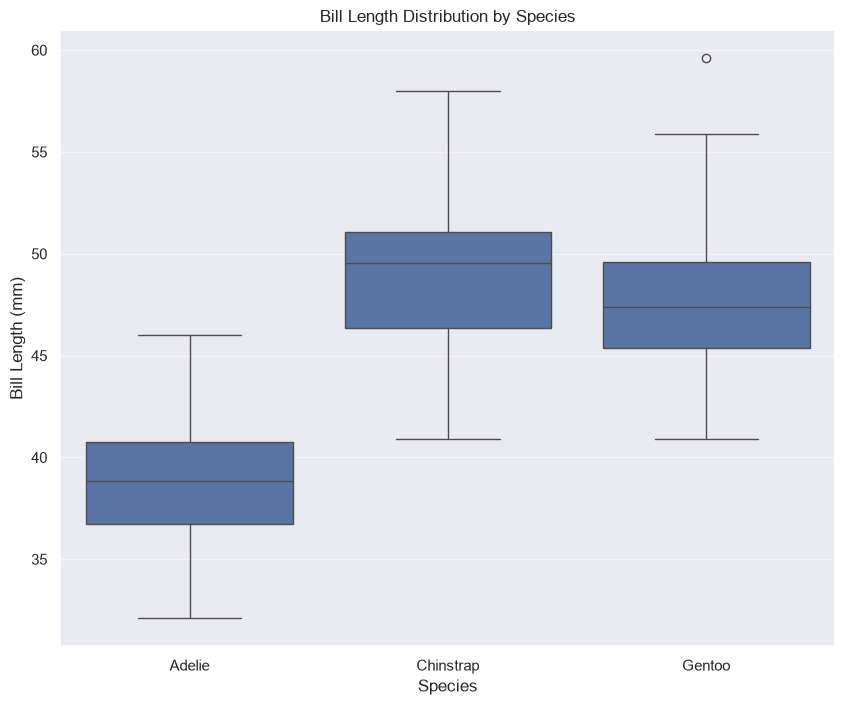

In [12]:
# Create a box plot using seaborn
plt.figure(figsize=(10, 8))
sns.boxplot(x='species', y='bill_length_mm', data=penguins)
plt.title('Bill Length Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Bill Length (mm)')
plt.show()

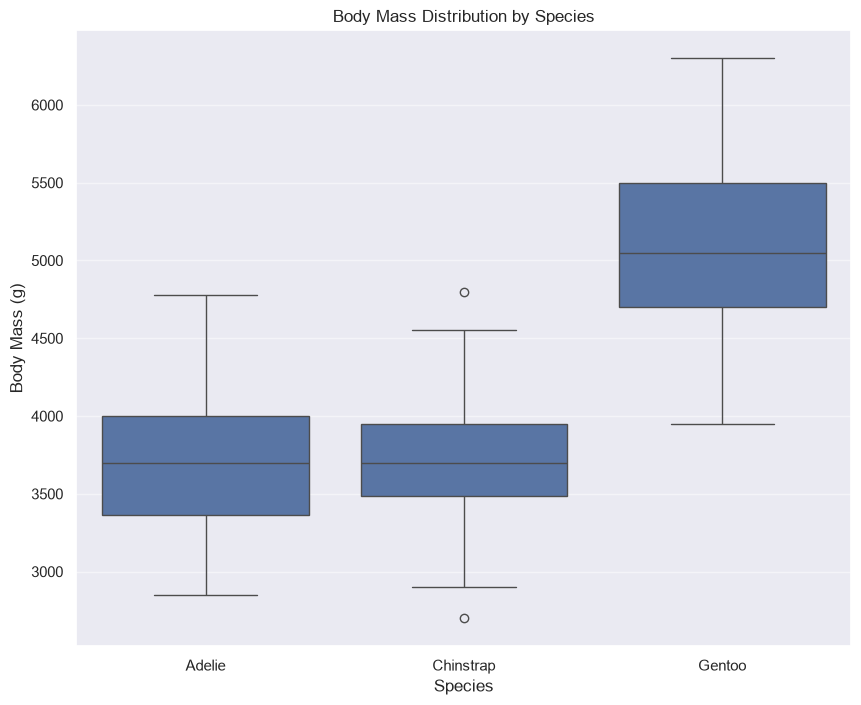

In [13]:
# Create a box plot using seaborn
plt.figure(figsize=(10, 8))
sns.boxplot(x='species', y='body_mass_g', data=penguins)
plt.title('Body Mass Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

In [14]:
print(variance_values)

bill_length_mm           29.906333
bill_depth_mm             3.877888
flipper_length_mm       196.441677
body_mass_g          648372.487699
dtype: float64


In [15]:
print(cov_matrix)

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm          29.906333      -2.462091          50.058195   
bill_depth_mm           -2.462091       3.877888         -15.947248   
flipper_length_mm       50.058195     -15.947248         196.441677   
body_mass_g           2595.623304    -748.456122        9852.191649   

                     body_mass_g  
bill_length_mm       2595.623304  
bill_depth_mm        -748.456122  
flipper_length_mm    9852.191649  
body_mass_g        648372.487699  


In [16]:
scaler = StandardScaler()
numeric_columns_standardized = scaler.fit_transform(numeric_columns)

# Convert the standardized array back to a DataFrame with column names
numeric_columns_standardized = pd.DataFrame(numeric_columns_standardized, columns=numeric_columns.columns)

# Calculate covariance matrix and variance for standardized variables
cov_matrix_ = numeric_columns_standardized.cov()
variance_values_ = numeric_columns_standardized.var()


In [17]:
print(variance_values_)

bill_length_mm       1.003012
bill_depth_mm        1.003012
flipper_length_mm    1.003012
body_mass_g          1.003012
dtype: float64


In [18]:
print(cov_matrix_)

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.003012      -0.229314           0.655063   
bill_depth_mm           -0.229314       1.003012          -0.579532   
flipper_length_mm        0.655063      -0.579532           1.003012   
body_mass_g              0.591227      -0.473437           0.875608   

                   body_mass_g  
bill_length_mm        0.591227  
bill_depth_mm        -0.473437  
flipper_length_mm     0.875608  
body_mass_g           1.003012  
